# Survival Analysis
## Advanced Lung Cancer Patients (the `lung` dataset)

North Central Cancer Treatment Group study of advanced lung cancer patients (Loprinzi et al.,
1994), bundled inside `lifelines` (`lifelines.datasets.load_lung`).

- `time`: days from enrollment to death or last follow-up.
- `status`: 1 if death was observed, 0 if the patient was still alive at last contact
  (**right-censored** -- we know they survived at least that long, not exactly how much longer).
- covariates: `age`, `sex` (1=male, 2=female), physician- and patient-rated performance scores
  (`ph.ecog`, `ph.karno`, `pat.karno`), caloric intake (`meal.cal`), and weight loss (`wt.loss`).

**Setup (run once, first):**


In [1]:
!pip install -q lifelines==0.30.3 scipy==1.16.1



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

import lifelines
from lifelines.datasets import load_lung
from lifelines.plotting import plot_lifetimes
from lifelines.statistics import logrank_test

RNG = np.random.default_rng(42)


In [3]:
df = load_lung()
print(df.shape)
df["sex_label"] = df["sex"].map({1: "Male", 2: "Female"})
df["sex_female"] = (df["sex"] == 2).astype(int)
df.isna().sum()


(228, 10)


inst           1
time           0
status         0
age            0
sex            0
ph.ecog        1
ph.karno       1
pat.karno      3
meal.cal      47
wt.loss       14
sex_label      0
sex_female     0
dtype: int64

**Chat, `meal.cal` is missing for 47 of 228 patients (~21%) — should I impute it or drop it?**

> With that much missingness and no strong reason to believe it's missing completely at random
> (sicker patients may be less likely to have completed a diet questionnaire), a quick imputation
> would risk quietly injecting bias into exactly the variable we'd be testing. Since this notebook
> isn't specifically about `meal.cal`, the simplest defensible choice is to exclude it from the
> regression covariates entirely and say so explicitly, rather than impute it and not mention the
> assumption that requires.


In [4]:
df.describe()


,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss,sex_female
count,227.000000,228.000000,228.000000,228.000000,228.000000,227.000000,227.000000,225.000000,181.000000,214.000000,228.000000
mean,11.088106,305.232456,0.723684,62.447368,1.394737,0.951542,81.938326,79.955556,928.779006,9.831776,0.394737
std,8.303491,210.645543,0.448159,9.073457,0.489870,0.717872,12.327955,14.623177,402.174707,13.139902,0.489870
min,1.000000,5.000000,0.000000,39.000000,1.000000,0.000000,50.000000,30.000000,96.000000,-24.000000,0.000000
25%,3.000000,166.750000,0.000000,56.000000,1.000000,0.000000,75.000000,70.000000,635.000000,0.000000,0.000000
50%,11.000000,255.500000,1.000000,63.000000,1.000000,1.000000,80.000000,80.000000,975.000000,7.000000,0.000000
75%,16.000000,396.500000,1.000000,69.000000,2.000000,1.000000,90.000000,90.000000,1150.000000,15.750000,1.000000
max,33.000000,1022.000000,1.000000,82.000000,2.000000,3.000000,100.000000,100.000000,2600.000000,68.000000,1.000000


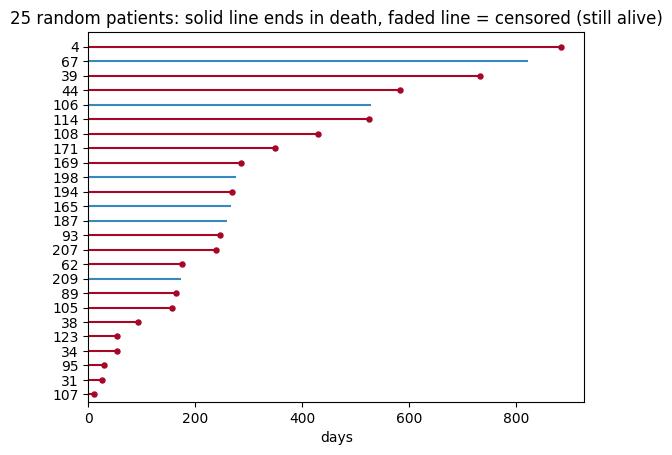

In [5]:
sample = df.sample(25, random_state=1)
plot_lifetimes(sample["time"], sample["status"])
plt.xlabel("days")
plt.title("25 random patients: solid line ends in death, faded line = censored (still alive)")
plt.show()


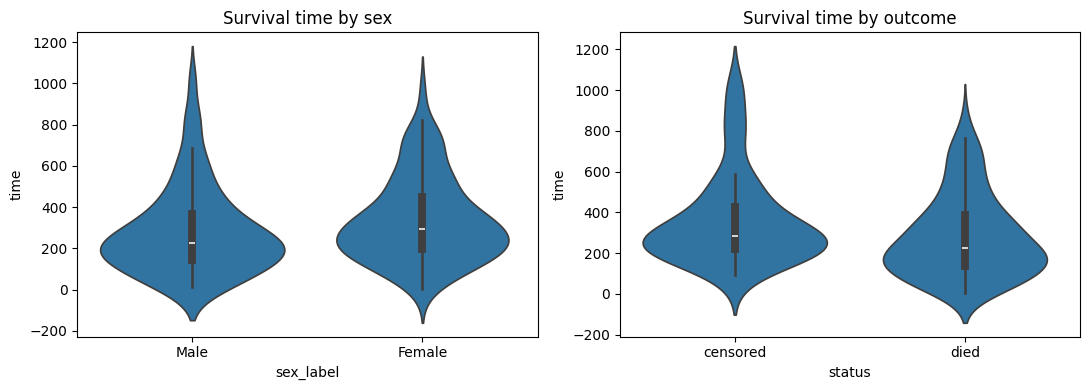

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.violinplot(x="sex_label", y="time", data=df, ax=ax[0])
ax[0].set_title("Survival time by sex")
sns.violinplot(x="status", y="time", data=df, ax=ax[1])
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["censored", "died"])
ax[1].set_title("Survival time by outcome")
plt.tight_layout()
plt.show()


**Chat, I get negative values in this violin plot even though survival time is strictly positive
-- what gives?**

> A violin plot draws a smoothed kernel density estimate and mirrors it left-right; the KDE kernel
> has infinite support, so its tails extend below zero even though no actual data point does. It's
> a rendering artifact of the smoothing, not a claim about negative survival times -- worth
> checking `df["time"].min()` directly if that's ever in doubt.


In [7]:
print("Minimum recorded survival/follow-up time:", df["time"].min(), "days")


Minimum recorded survival/follow-up time: 5 days


## The naive default: T ~ Exponential(λ), and why ignoring censoring is a real mistake here

**Chat, why is the exponential distribution the traditional default for time-to-event data, and
why might it be a poor fit for lung cancer survival specifically?**

> The exponential distribution is the unique continuous distribution with a **constant hazard
> rate** (memorylessness: the chance of the event in the next instant doesn't depend on how long
> you've already survived) -- a natural, simple starting assumption when nothing else is known.
> It's a poor fit for progressive diseases like advanced lung cancer specifically because risk
> typically *increases* with time since diagnosis as the disease advances, which a constant-hazard
> model cannot represent -- a case for the Weibull distribution instead, which allows the hazard to
> rise or fall over time via its shape parameter.


In [8]:
# The naive, censoring-blind fit
loc, scale_naive = ss.expon.fit(df["time"], floc=0)
print(f"Naive scipy exponential fit (ignores censoring): mean survival = {scale_naive:.1f} days")

# The censoring-aware fit
from lifelines import ExponentialFitter, WeibullFitter
ef = ExponentialFitter().fit(df["time"], event_observed=df["status"])
print(f"Censoring-aware ExponentialFitter: mean survival = {ef.lambda_:.1f} days")

pct_bias = 100 * abs(scale_naive - ef.lambda_) / ef.lambda_
print(f"\nNaive fit understates mean survival by {pct_bias:.1f}% relative to the censoring-aware fit")


Naive scipy exponential fit (ignores censoring): mean survival = 305.2 days
Censoring-aware ExponentialFitter: mean survival = 421.8 days

Naive fit understates mean survival by 27.6% relative to the censoring-aware fit


Weibull fit (lifelines, censoring-aware): rho=1.317, lambda=417.8

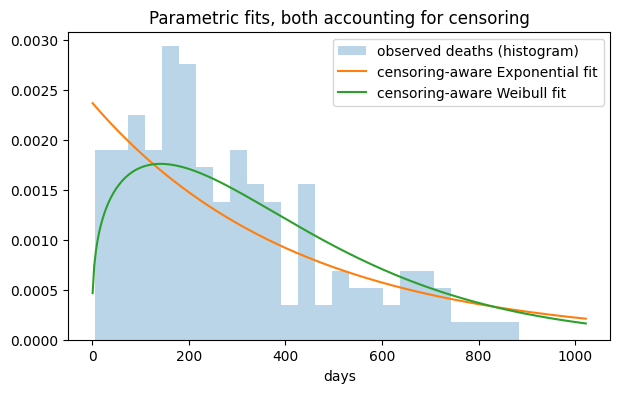

In [9]:
wf = WeibullFitter().fit(df["time"], event_observed=df["status"])
print(f"Weibull fit (lifelines, censoring-aware): rho={wf.rho_:.3f}, lambda={wf.lambda_:.1f}")

x = np.linspace(1, df["time"].max(), 300)
rho_, lambda_ = wf.rho_, wf.lambda_
weibull_pdf = (rho_ / lambda_) * (x / lambda_) ** (rho_ - 1) * np.exp(-(x / lambda_) ** rho_)
exp_pdf = ss.expon.pdf(x, scale=ef.lambda_)

plt.figure(figsize=(7, 4))
plt.hist(df.loc[df["status"] == 1, "time"], bins=25, density=True, alpha=0.3, label="observed deaths (histogram)")
plt.plot(x, exp_pdf, label="censoring-aware Exponential fit")
plt.plot(x, weibull_pdf, label="censoring-aware Weibull fit")
plt.legend(); plt.xlabel("days"); plt.title("Parametric fits, both accounting for censoring")
plt.show()


**Chat, what does the fitted Weibull shape parameter (`rho ≈ 1.32`) tell us here?**

> `rho = 1` would reduce the Weibull to the plain exponential (constant hazard); `rho > 1` means
> the hazard *increases* with time since enrollment, and `rho < 1` would mean it decreases.
> `rho ≈ 1.32` -- moderately, not just marginally, above 1 -- says the risk of death does rise as
> follow-up time accumulates. It's worth being precise about the size of the effect rather than
> just its direction: this is a real but *moderate* upward slope in the hazard, not a dramatic
> one -- a `rho` around 3-5 would indicate a much more sharply accelerating hazard than what this
> cohort actually shows.


### Nonparametric: the empirical survival function


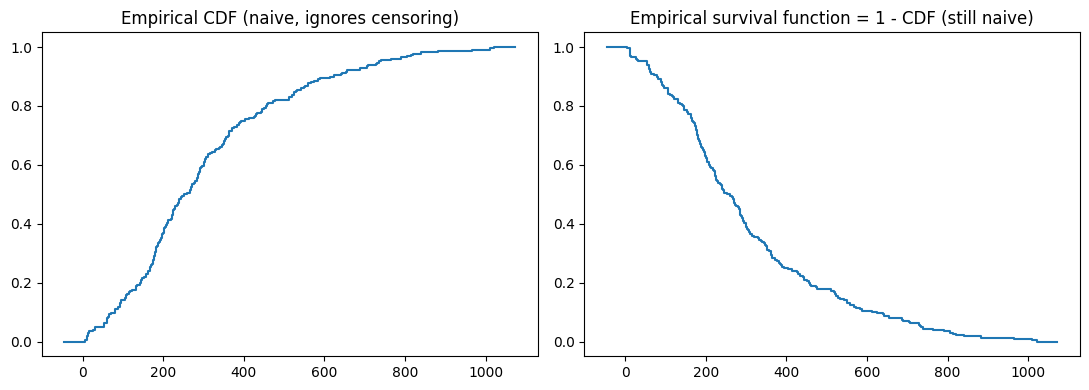

In [10]:
ecdf = ss.ecdf(df["time"])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ecdf.cdf.plot(ax[0]); ax[0].set_title("Empirical CDF (naive, ignores censoring)")
ecdf.sf.plot(ax[1]); ax[1].set_title("Empirical survival function = 1 - CDF (still naive)")
plt.tight_layout()
plt.show()


**Chat, what's wrong with the naive estimator "1 - ECDF" once censoring is present, and what's the
fix?**

> `scipy.stats.ecdf` has no notion of censoring either -- it treats every recorded `time` as an
> exact observed event, so a patient who was merely *last seen alive* on day 300 counts as having
> "failed" on day 300, which biases the tail of the survival curve downward (understating
> survival), and understates the true variance at the tail where censoring accumulates. The fix is
> the **Kaplan-Meier estimator**: at each observed death time, it only reduces the survival
> estimate using the patients still known to be at risk (alive and *un-censored* up to that
> point), correctly leaving censored patients in the risk set for as long as they were actually
> observed and simply removing them (without counting a "death") once they're censored.


          KM_estimate
timeline             
0.0          1.000000
5.0          0.995614
11.0         0.982456
12.0         0.978070
13.0         0.969298


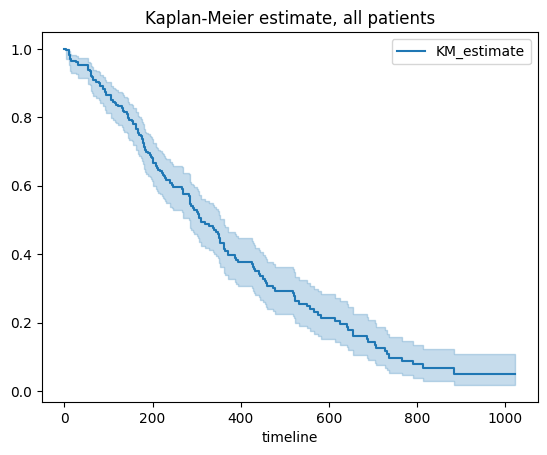

In [11]:
kmf = lifelines.KaplanMeierFitter()
kmf.fit(df["time"], df["status"])
print(kmf.survival_function_.head())
ax = kmf.plot_survival_function()
ax.set_title("Kaplan-Meier estimate, all patients")
plt.show()


**Chat, how does `lifelines` compute the confidence band around the KM curve, and why does it use
a log(-log(x)) transform?**

> By default via **Greenwood's formula**, which gives the variance of the KM estimator at each
> time point as a sum over prior risk sets. Naively building a symmetric interval directly on the
> survival probability can push the interval outside `[0, 1]` (especially near the ends of follow-
> up, where the curve is close to 0 or 1). Transforming through `log(-log(S(t)))` first — which
> maps `(0, 1)` onto the whole real line — lets us build a normal-approximation interval on an
> unbounded scale (via the delta method) and then transform back, guaranteeing the final interval
> stays inside `[0, 1]` by construction.


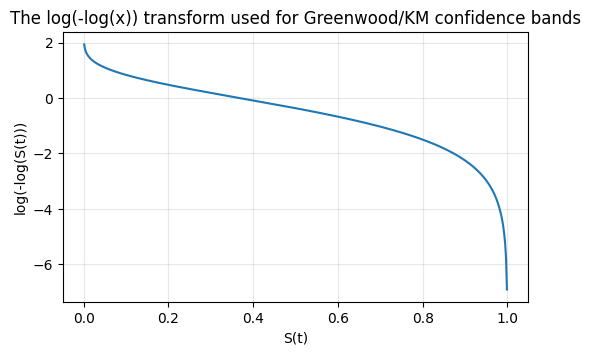

In [12]:
x_ll = np.linspace(1e-3, 1 - 1e-3, 500)
y_ll = np.log(-np.log(x_ll))
plt.figure(figsize=(6, 3.5))
plt.plot(x_ll, y_ll)
plt.xlabel("S(t)"); plt.ylabel("log(-log(S(t)))")
plt.title("The log(-log(x)) transform used for Greenwood/KM confidence bands")
plt.grid(alpha=0.3)
plt.show()


### Cumulative hazard: Nelson-Aalen


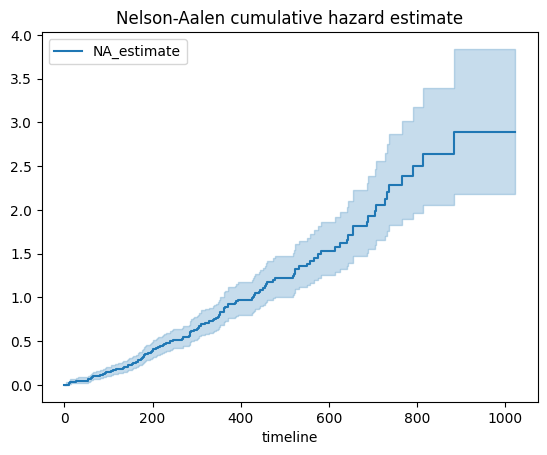

In [13]:
naf = lifelines.NelsonAalenFitter()
naf.fit(df["time"], df["status"])
ax = naf.plot_cumulative_hazard()
ax.set_title("Nelson-Aalen cumulative hazard estimate")
plt.show()


**Chat, why not just estimate the cumulative hazard as `-log(KM survival)` instead of using a
separate Nelson-Aalen estimator?**

> `S(t) = exp(-H(t))` is an exact mathematical identity, so `-log(KM)` is a perfectly valid
> *point* estimate of the cumulative hazard `H(t)`. The issue is with propagating uncertainty
> through that transform: `-log(x)` is convex, so by Jensen's inequality
> `E[-log(X)] >= -log(E[X])`, meaning naively pushing the KM estimator's expectation through the
> log transform introduces a small systematic (upward) bias that grows exactly where the sample
> size thins out — precisely where survival analysis needs its uncertainty estimates to be most
> trustworthy. Nelson-Aalen estimates the cumulative hazard directly (as a sum of `d_i / n_i` over
> observed death times) without that transform, avoiding the issue at its source.


## Two groups: does sex predict survival?


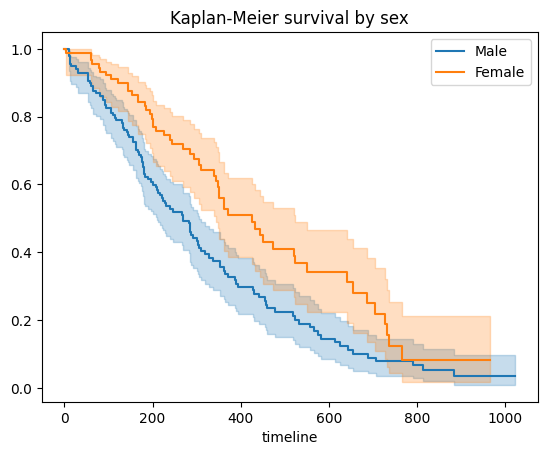

In [14]:
kmf_m = lifelines.KaplanMeierFitter()
kmf_m.fit(df.loc[df["sex_label"] == "Male", "time"], df.loc[df["sex_label"] == "Male", "status"], label="Male")
ax = kmf_m.plot_survival_function()

kmf_f = lifelines.KaplanMeierFitter()
kmf_f.fit(df.loc[df["sex_label"] == "Female", "time"], df.loc[df["sex_label"] == "Female", "status"], label="Female")
kmf_f.plot_survival_function(ax=ax)
ax.set_title("Kaplan-Meier survival by sex")
plt.show()


**Chat, the two curves look different — how do I test whether that's statistically meaningful, and
what should I do next if it is?**

> The standard nonparametric test for "are these two survival curves the same" is the **log-rank
> test**, which compares observed vs. expected deaths in each group at every event time (under the
> null that the groups share one hazard function) and combines them into a single chi-squared
> statistic. If it comes back significant, the natural next step is **Cox regression**, which lets
> us quantify *how much* the hazard differs (as a hazard ratio) and adjust for other covariates
> simultaneously, rather than only testing whether a difference exists.


In [15]:
res = logrank_test(
    df.loc[df["sex_label"] == "Male", "time"], df.loc[df["sex_label"] == "Female", "time"],
    event_observed_A=df.loc[df["sex_label"] == "Male", "status"],
    event_observed_B=df.loc[df["sex_label"] == "Female", "status"],
)
res.print_summary()


## Cox proportional-hazards regression


**Chat, explain the Cox model: what does "semi-parametric" mean here, and why is there no
intercept?**

> The Cox model writes the hazard for subject `i` as `h_i(t) = h_0(t) * exp(beta . x_i)`: an
> unspecified (nonparametric) **baseline hazard** `h_0(t)` shared by everyone, scaled up or down
> by each subject's own covariates through an `exp(beta . x)` multiplier (parametric part) — hence
> "semi-parametric." The trick that makes fitting it possible without ever specifying `h_0(t)`
> explicitly is the **partial likelihood**: at each observed death time, it only asks "of everyone
> still at risk at this moment, what's the probability the actual victim was the one who died,
> given their relative hazards" — the unknown, shared `h_0(t)` cancels out of that ratio entirely.
> There's no intercept because a constant offset to `beta . x` would just rescale `h_0(t)` by a
> constant factor, which the baseline hazard — free to be *any* function of time — already absorbs
> completely; an intercept here would be entirely unidentifiable.


In [16]:
cox_cols = ["time", "status", "age", "sex_female", "ph.ecog", "wt.loss"]
cox_df = df[cox_cols].dropna()
print(f"Using {len(cox_df)} of {len(df)} patients with complete data on the chosen covariates")

cph = lifelines.CoxPHFitter()
cph.fit(cox_df, duration_col="time", event_col="status")
cph.print_summary()


Using 213 of 228 patients with complete data on the chosen covariates


<lifelines.CoxPHFitter: fitted with 213 total observations, 62 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 213
number of events observed = 151
   partial log-likelihood = -659.51
         time fit was run = 2026-09-10 12:07:35 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age         0.01      1.01      0.01           -0.01            0.03                0.99                1.03
sex_female -0.59      0.55      0.18           -0.93           -0.25                0.39                0.78
ph.ecog     0.52      1.67      0.13            0.27            0.76                1.31                2.14
wt.loss    -0.01      0.99      0.01           -0.02            0.00                0.98                1.00

            cmp to     z      p  -log2(p)
covariate                                
age           0.00  1.39   0.16      2.60
sex_female    0.00 -3.37 <0.005     10.37
ph.ecog       0.00  4.09 <0.005     14.49
wt.loss       0.00 -1.35   0.18      2.51
---
Concordance = 0.65
Partial AIC = 1327.03
log-likelihood ratio test = 31.02 on 4 df
-log2(p) of ll-ratio test = 18.33

**Chat, explain this lifelines output — which covariates matter, and how do I read the hazard
ratios (`exp(coef)`)?**

> Each `exp(coef)` is a **hazard ratio**: how much a one-unit increase in that covariate multiplies
> the hazard, holding the others fixed. A hazard ratio above 1 means higher risk (shorter survival)
> per unit increase; below 1 means protective. `ph.ecog` (physician-rated performance status,
> where higher = more disabled) typically comes out with a hazard ratio clearly above 1 and a small
> p-value here — worse baseline function predicts faster progression, which matches clinical
> intuition and is usually the strongest single predictor in this dataset. `concordance_index`
> reported above measures how often the model correctly orders *pairs* of patients by risk (0.5 =
> coin flip, 1.0 = perfect ranking) — a useful, if optimistic, summary of the model's discriminative
> power.


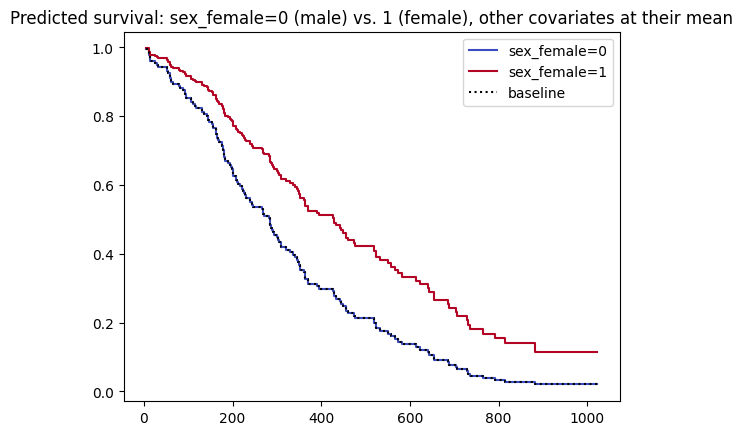

In [17]:
cph.plot_partial_effects_on_outcome(covariates="sex_female", values=[0, 1], cmap="coolwarm")
plt.title("Predicted survival: sex_female=0 (male) vs. 1 (female), other covariates at their mean")
plt.show()


**Chat, the Cox model never specified a baseline hazard function, so how can `lifelines` draw an
actual survival curve here?**

> Via **Breslow's estimator**: once the partial likelihood has given us `beta`, we go back and
> estimate the baseline cumulative hazard nonparametrically from the same data (essentially a
> Nelson-Aalen-style estimate built from the residual risk after accounting for each subject's
> `exp(beta . x)`), then combine `H_0(t)` with a chosen covariate profile via
> `S(t | x) = S_0(t)^exp(beta . x)` to get an actual, plottable survival curve for any covariate
> combination.


### Checking the proportional-hazards assumption



   Bootstrapping lowess lines. May take a moment...




   Bootstrapping lowess lines. May take a moment...




   Bootstrapping lowess lines. May take a moment...




   Bootstrapping lowess lines. May take a moment...



Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.5422)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6656)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0973)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0869)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1698)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1801)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6557)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7280)'>]]

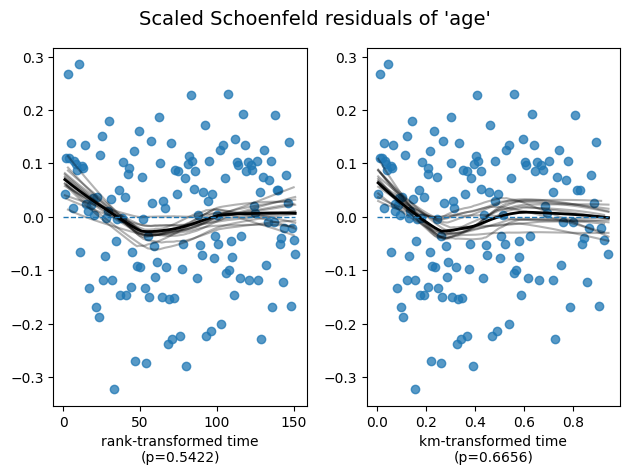

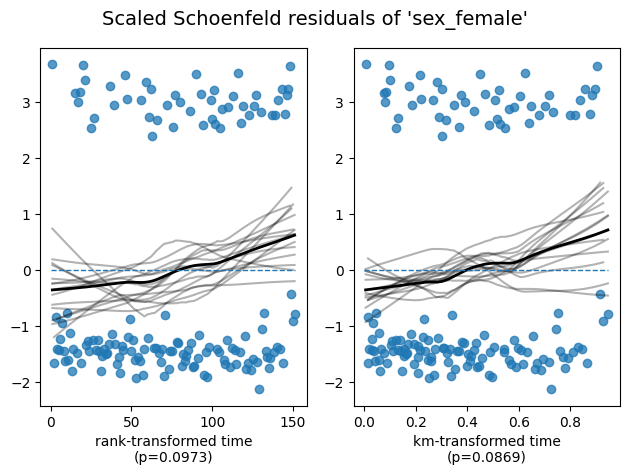

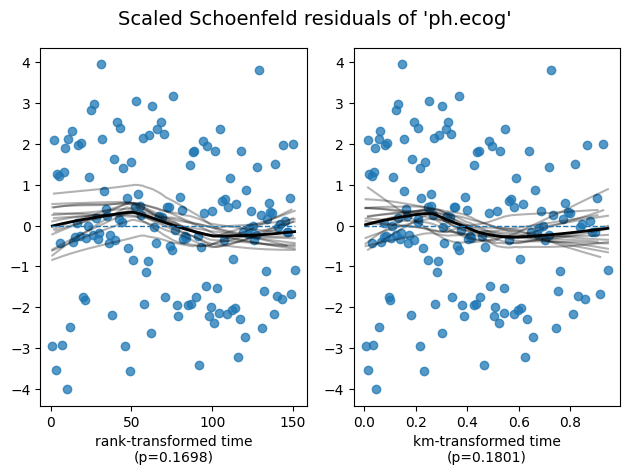

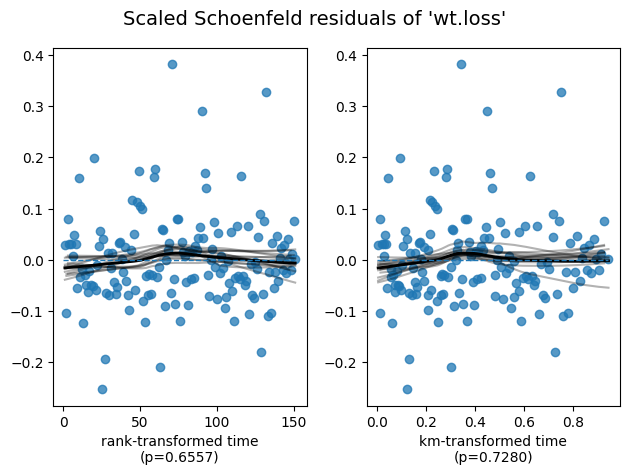

In [18]:
cph.check_assumptions(cox_df, show_plots=True, p_value_threshold=0.05)


**Chat, what are scaled Schoenfeld residuals, and what does this check tell me?**

> The proportional-hazards assumption says each covariate's *effect on the log-hazard* is constant
> over time. Scaled Schoenfeld residuals give, for each covariate and each observed death, a
> measure of how much that subject's covariate value deviated from what the model expected *at
> that specific time* — plotting them against time (or a rank/KM-based transform of time, both
> options `lifelines` offers) and testing for a nonzero slope directly tests "is this covariate's
> effect drifting over the follow-up period rather than staying constant." A significant trend for
> any covariate above means the flagged variable may need a time-varying coefficient or a
> stratified model instead of being trusted as a single constant hazard ratio for the whole study
> period.
